# Interpretasi Penamaan Klaster dengan WordCloud 

## Import Library

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

print("Library berhasil diimpor.")

Library berhasil diimpor.


## Load Data

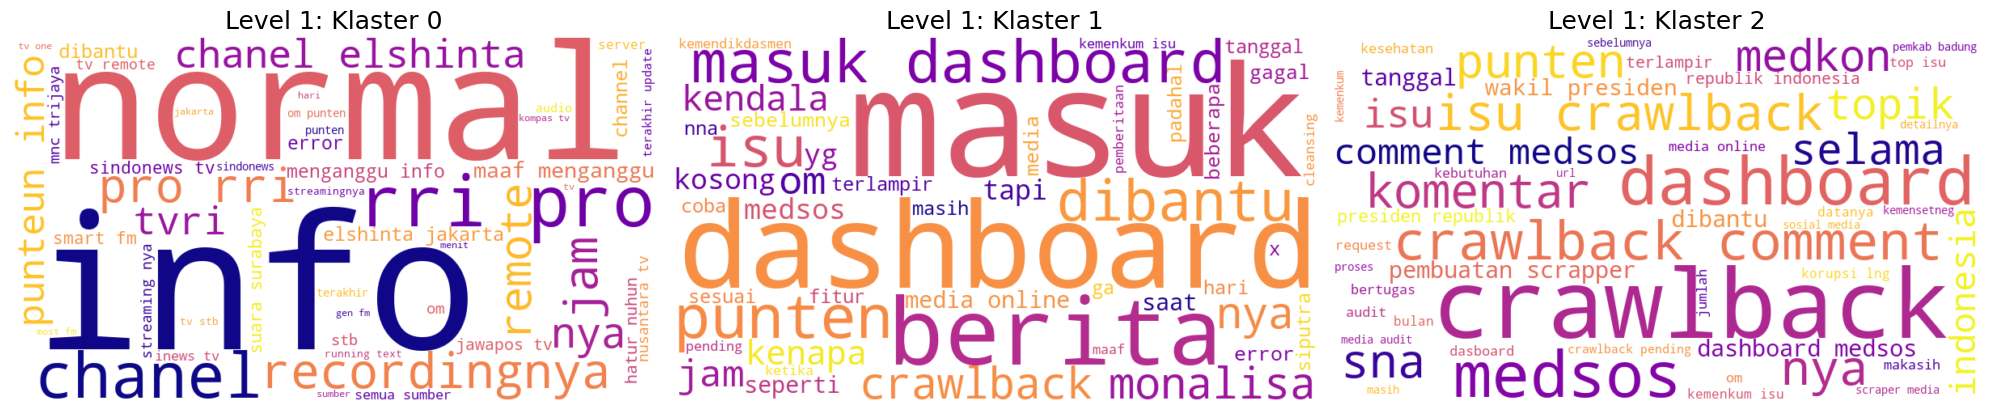

In [15]:
# 1. Load hasil gabungan Level 1
df_l1 = pd.read_csv('../hasil/Hasil_Cluster_L1_K3.csv')

# 2. Daftar Nama Klien (Estraksi dari Dataset)
client_names = [
    'setwapres', 'bps', 'heinz', 'telkomsel', 'kai', 'mrt', 'damri', 'asdp', 
    'jasamarga', 'bjb', 'bkpm', 'bpom', 'bpjs', 'bsi', 'kemlu', 'kci', 'commuter',
    'telkom', 'isuzu', 'shopee', 'heinz', 'wilmar', 'mubadala', 'medco', 'pertamina',
    'astra', 'bsi', 'icdx', 'jasa', 'marga', 'garuda', 'pulp', 'lestari', 'toba',
    'paud', 'kemdikbud', 'dpr', 'polres', 'polri', 'commuterline', 'siputri', 'rri pro',
]

# 3. Daftar Stopwords Lengkap (Kombinasi Umum + Klien)
custom_stopwords = [
    # Kata sapaan & formalitas helpdesk
    'tim', 'it', 'mohon', 'siang', 'selamat', 'pagi', 'sore', 'malam', 
    'terima', 'kasih', 'bantuannya', 'bantuan', 'minta', 'tolong', 
    'cek', 'dicek', 'mas', 'mbak', 'halo', 'terimakasih', 'hi', 'admin',
    
    # Kata kerja umum & keterangan
    'input', 'data', 'link', 'sudah', 'belum', 'akan', 'bisa', 'harus',
    'ada', 'tidak', 'boleh', 'mau', 'ingin', 'dapat', 'melakukan', 'terjadi',
    'muncul', 'pakai', 'menggunakan', 'kembali', 'lagi', 'tadi', 'baru',
    'berikut', 'lampirkan', 'informasi', 'terkait', 'mengenai', 'adanya',
    'bantu', 'recording', 'mati', 
    
    # Konjungsi & Preposisi
    'di', 'untuk', 'dengan', 'dan', 'yang', 'ini', 'itu', 'saya', 'kamu', 
    'dia', 'kami', 'kalian', 'mereka', 'adalah', 'dari', 'ke', 'sebagai', 
    'pada', 'oleh', 'karena', 'sehingga', 'jika', 'atau', 'tetapi', 'namun', 
    'juga', 'saja', 'hanya', 'serta', 'bahwa', 'dalam', 'secara', 'melalui',
    'yaa', 'ya', 'agar', 
    
    # Kata Lain yang sering muncul tapi bukan inti masalah
    'keyword', 'akun', 'postingan', 'periode', 'akun', 'tersebut', 'linknya',
    'sebagai', 'informasi', 'akibat', 'unit', 'perihal', 'is', 'the', 'to', 'at'
]

# Gabungkan dengan nama klien
final_stopwords = set(custom_stopwords + client_names)

def show_l1_wordclouds(df):
    unique_clusters = sorted(df['KLASTER'].unique())
    plt.figure(figsize=(20, 10))
    
    for i, cluster_id in enumerate(unique_clusters):
        text = " ".join(df[df['KLASTER'] == cluster_id]['CLEAN_TEXT'].astype(str))
        
        wc = WordCloud(
            width=800, 
            height=450,
            background_color='white',
            stopwords=final_stopwords,
            colormap='plasma',
            max_words=50,
            min_font_size=12
        ).generate(text)
        
        plt.subplot(1, 3, i + 1)
        plt.imshow(wc, interpolation='bilinear')
        plt.title(f"Level 1: Klaster {cluster_id}", fontsize=18)
        plt.axis('off')
    
    plt.tight_layout()
    plt.savefig('../hasil/WordCloud_L1_K3_TanpaKlien.png', dpi=300)
    plt.show()

# Jalankan fungsi
show_l1_wordclouds(df_l1)